# Per-area encoder: cosine similarity and 2-AFC

Compares test-set SigLIP cosine similarity and 2-AFC identification accuracy for encoders trained on each individual brain area (TE0, TE2, TE3, PRH, PHC) and the compound regions IT (TE0+TE2+TE3) and MT (PHC+PRH).

In [15]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
from config_const import CHECKPOINT_DIR


In [16]:
AREAS = ['TE0', 'TE2', 'TE3', 'IT', 'PRH', 'PHC', 'MT']
AREA_COLORS = {
    'TE0': '#4e79a7', 'TE2': '#f28e2b', 'TE3': '#e15759',
    'IT':  '#76b7b2',
    'PRH': '#59a14f', 'PHC': '#b07aa1',
    'MT':  '#ff9da7',
}

NCE_WEIGHT = 0.1  # select runs trained with this nce-weight


def load_area_ckpt(area: str, nce_weight: float = NCE_WEIGHT) -> dict | None:
    base = CHECKPOINT_DIR / 'multihead' / f'hvm_{area}'
    if not base.exists():
        return None
    tag = f'_nw{nce_weight}_'
    candidates = [d / 'best.pt' for d in base.iterdir()
                  if tag in d.name and (d / 'best.pt').exists()]
    if not candidates:
        return None
    ckpt = torch.load(candidates[0], weights_only=False, map_location='cpu')
    return {
        'area':      area,
        'val_cos':   ckpt['metrics']['val_cos_siglip'],
        'val_2afc':  ckpt['metrics']['val_2afc_siglip'],
        'test_cos':  ckpt['test_metrics']['test_cos_siglip'],
        'test_2afc': ckpt['test_metrics']['test_2afc_siglip'],
        'test_top1': ckpt['test_metrics']['test_top1_siglip'],
        'test_top5': ckpt['test_metrics']['test_top5_siglip'],
    }

results = {a: r for a in AREAS if (r := load_area_ckpt(a)) is not None}
for a, r in results.items():
    print(f"{a:4s}  val_cos={r['val_cos']:.3f}  val_2afc={r['val_2afc']:.3f}  "
          f"test_cos={r['test_cos']:.3f}  test_2afc={r['test_2afc']:.3f}  "
          f"top1={r['test_top1']:.3f}  top5={r['test_top5']:.3f}")


TE0   val_cos=0.805  val_2afc=0.619  test_cos=0.802  test_2afc=0.616  top1=0.022  top5=0.111
TE2   val_cos=0.844  val_2afc=0.541  test_cos=0.837  test_2afc=0.540  top1=0.022  top5=0.067
TE3   val_cos=0.834  val_2afc=0.605  test_cos=0.829  test_2afc=0.617  top1=0.022  top5=0.089
IT    val_cos=0.817  val_2afc=0.608  test_cos=0.816  test_2afc=0.625  top1=0.033  top5=0.100
PRH   val_cos=0.847  val_2afc=0.505  test_cos=0.841  test_2afc=0.495  top1=0.011  top5=0.044
PHC   val_cos=0.842  val_2afc=0.602  test_cos=0.834  test_2afc=0.612  top1=0.022  top5=0.133
MT    val_cos=0.844  val_2afc=0.552  test_cos=0.838  test_2afc=0.564  top1=0.022  top5=0.089


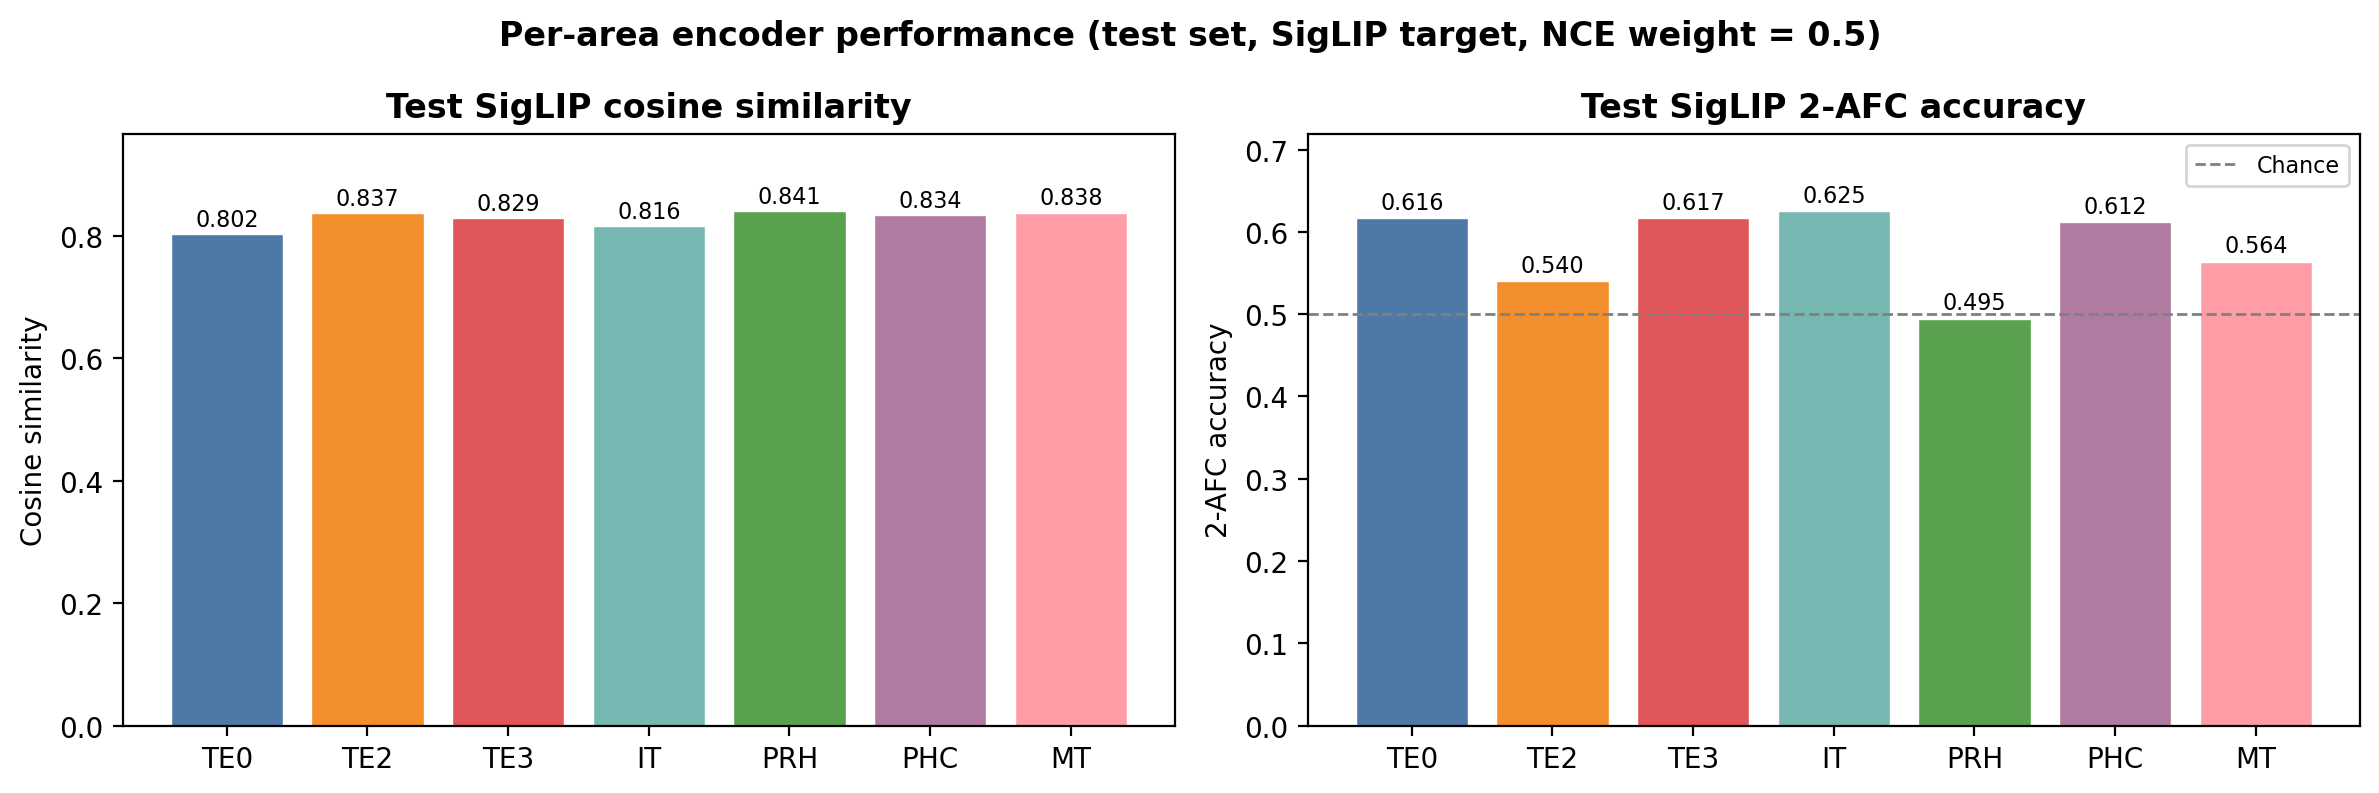

In [17]:
areas_present = [a for a in AREAS if a in results]
x = np.arange(len(areas_present))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = [AREA_COLORS[a] for a in areas_present]

for ax, key, ylabel, title, chance in [
    (axes[0], 'test_cos',  'Cosine similarity', 'Test SigLIP cosine similarity', None),
    (axes[1], 'test_2afc', '2-AFC accuracy',    'Test SigLIP 2-AFC accuracy',    0.5),
]:
    vals = [results[a][key] for a in areas_present]
    bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
    if chance is not None:
        ax.axhline(chance, color='grey', ls='--', lw=1, label='Chance')
        ax.legend(fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(areas_present, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, min(1.05, max(vals) * 1.15))

fig.suptitle('Per-area encoder performance (test set, SigLIP target, NCE weight = 0.5)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()


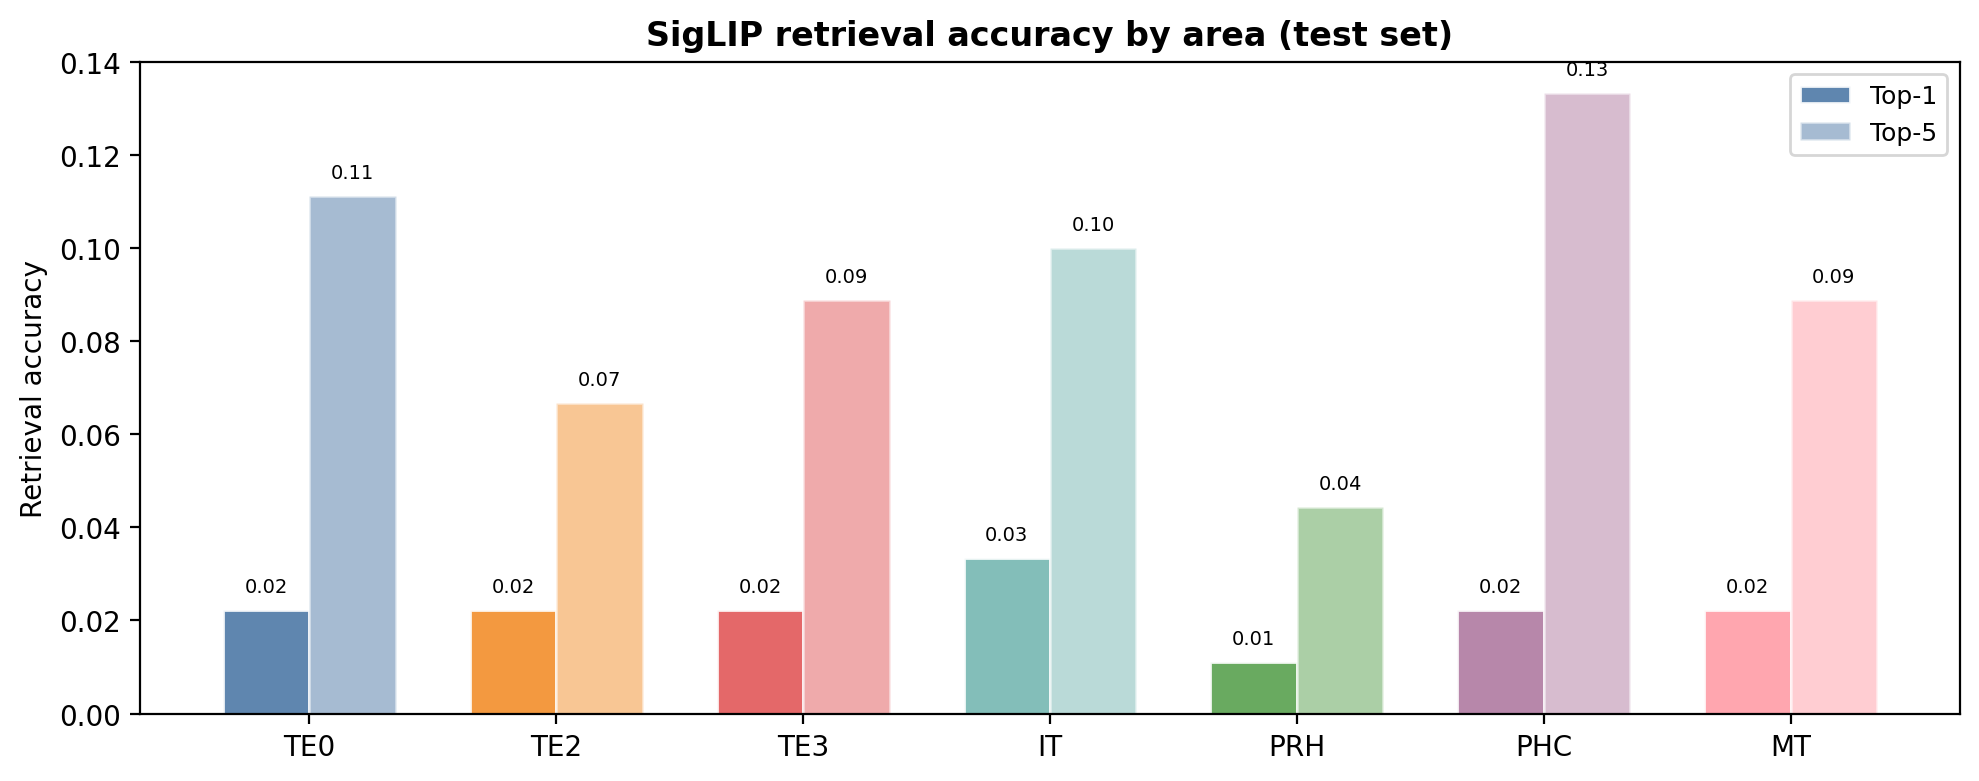

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
w = 0.35
x = np.arange(len(areas_present))

top1 = [results[a]['test_top1'] for a in areas_present]
top5 = [results[a]['test_top5'] for a in areas_present]

b1 = ax.bar(x - w/2, top1, w, color=colors, edgecolor='white', label='Top-1', alpha=0.9)
b5 = ax.bar(x + w/2, top5, w, color=colors, edgecolor='white', label='Top-5', alpha=0.5)

for bars, vals in [(b1, top1), (b5, top5)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003, f'{v:.2f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(areas_present, fontsize=10)
ax.set_ylabel('Retrieval accuracy')
ax.set_title('SigLIP retrieval accuracy by area (test set)', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


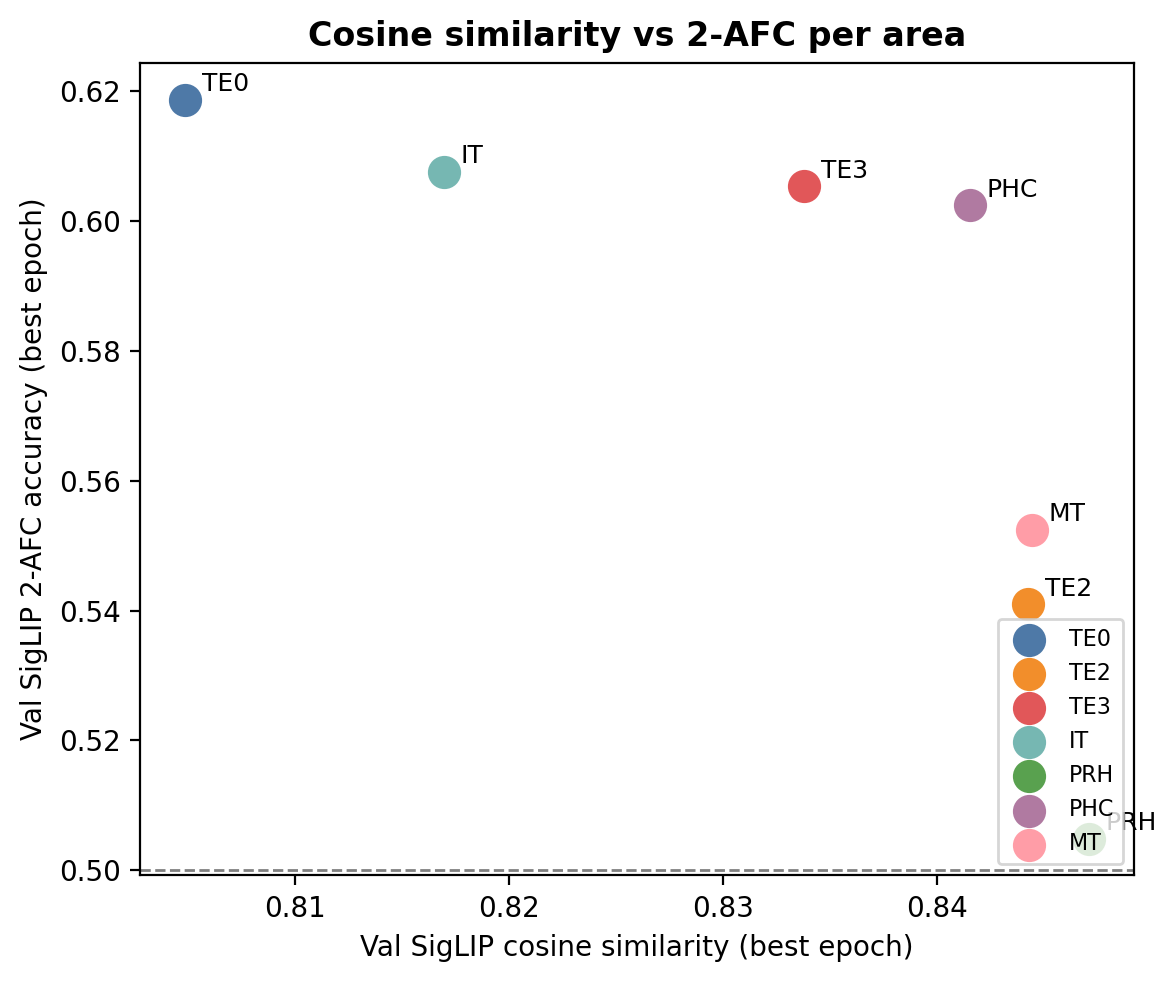

In [19]:
# Reload checkpoints for val curves (last.pt has the full training trace if logged,
# but we only saved scalars at best epoch — plot the best-epoch marker per area instead)
# For a training curve we need to reload all saved last.pt metrics; here we just
# show the per-area best val cos and 2afc as a scatter to reveal the cos/2afc relationship.

fig, ax = plt.subplots(figsize=(6, 5))
for a in areas_present:
    r = results[a]
    ax.scatter(r['val_cos'], r['val_2afc'], color=AREA_COLORS[a], s=120, zorder=3, label=a)
    ax.annotate(a, (r['val_cos'], r['val_2afc']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)

ax.axhline(0.5, color='grey', ls='--', lw=1)
ax.set_xlabel('Val SigLIP cosine similarity (best epoch)')
ax.set_ylabel('Val SigLIP 2-AFC accuracy (best epoch)')
ax.set_title('Cosine similarity vs 2-AFC per area', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
fig.tight_layout()
plt.show()


In [20]:
# DFE (dimension-wise fraction of explained variance) per area.
#
# DFE is defined as the mean squared Pearson r between predicted and true
# SigLIP across the 90 test stimuli, computed per SigLIP dimension then
# averaged.  This is distinct from R² (1 - SS_res/SS_tot): because both
# pred and gt are L2-normalized, per-dimension variance is tiny (~0.015 std)
# and SS_res easily exceeds SS_tot, making R² severely negative even when
# the predictions are directionally correct.  Squared Pearson r is the right
# quantity for unit-sphere data: it measures correlation structure independent
# of scale.

from data_utils.hvm_loader import _load_hvm_neural, _category_stratified_split
from encoders.multihead import MultiHeadTransformer

_, _, test_idx = _category_stratified_split(seed=42)
gt_siglip = torch.load('cache/hvm_siglip_embeddings.pt', map_location='cpu').float()
gt_test = gt_siglip[test_idx].numpy()  # (90, 1152)


def load_model_and_predict(area: str, nce_weight: float = NCE_WEIGHT):
    base = CHECKPOINT_DIR / 'multihead' / f'hvm_{area}'
    tag = f'_nw{nce_weight}_'
    candidates = [d / 'best.pt' for d in base.iterdir()
                  if tag in d.name and (d / 'best.pt').exists()]
    if not candidates:
        return None
    ckpt = torch.load(candidates[0], weights_only=False, map_location='cpu')
    args = ckpt['args']
    state = ckpt['model_state']

    rsp, _, _ = _load_hvm_neural(area=area)
    rsp_test = rsp[test_idx]  # (90, N, T)
    rsp_t = torch.tensor(rsp_test, dtype=torch.float32).permute(0, 2, 1)  # (90, T, N)
    n_neurons = rsp_t.shape[2]

    model = MultiHeadTransformer(
        n_neurons=n_neurons, d_model=args['d_model'], n_heads=args['n_heads'],
        n_layers=args['n_layers'], shared_dim=args['shared_dim'],
        dropout=args['dropout'], n_categories=0,
    )
    model.load_state_dict(state)
    model.eval()
    with torch.no_grad():
        pred = model(rsp_t)['siglip'].numpy()  # (90, 1152)
    return pred


def compute_dfe(pred, gt):
    """Squared Pearson r per SigLIP dimension, vectorized."""
    # z-score each column independently
    def _zs(x):
        mu = x.mean(axis=0, keepdims=True)
        sd = x.std(axis=0, keepdims=True)
        return np.where(sd > 0, (x - mu) / sd, 0.0)
    zp = _zs(pred)
    zg = _zs(gt)
    r = (zp * zg).mean(axis=0)   # Pearson r per dim, shape (D,)
    return r ** 2                  # DFE per dim


dfe_results = {}
for area in areas_present:
    pred = load_model_and_predict(area)
    if pred is None:
        continue
    dfe = compute_dfe(pred, gt_test)
    dfe_results[area] = dfe
    print(f"{area:4s}  mean_DFE={dfe.mean():.4f}  median_DFE={np.median(dfe):.4f}  "
          f"frac>0.01={np.mean(dfe > 0.01):.3f}")


Loading HVM sessions:   0%|          | 0/5 [00:00<?, ?it/s]

Loading HVM sessions: 100%|██████████| 10/10 [00:04<00:00,  2.48it/s]
/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TE0   mean_DFE=0.0196  median_DFE=0.0088  frac>0.01=0.461


Loading HVM sessions: 100%|██████████| 10/10 [00:04<00:00,  2.46it/s]
/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TE2   mean_DFE=0.0150  median_DFE=0.0064  frac>0.01=0.416


...

Loading HVM sessions: 100%|██████████| 10/10 [00:03<00:00,  2.51it/s]
/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


PHC   mean_DFE=0.0240  median_DFE=0.0114  frac>0.01=0.522


Loading HVM sessions: 100%|██████████| 10/10 [00:03<00:00,  2.53it/s]


MT    mean_DFE=0.0187  median_DFE=0.0095  frac>0.01=0.484


/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


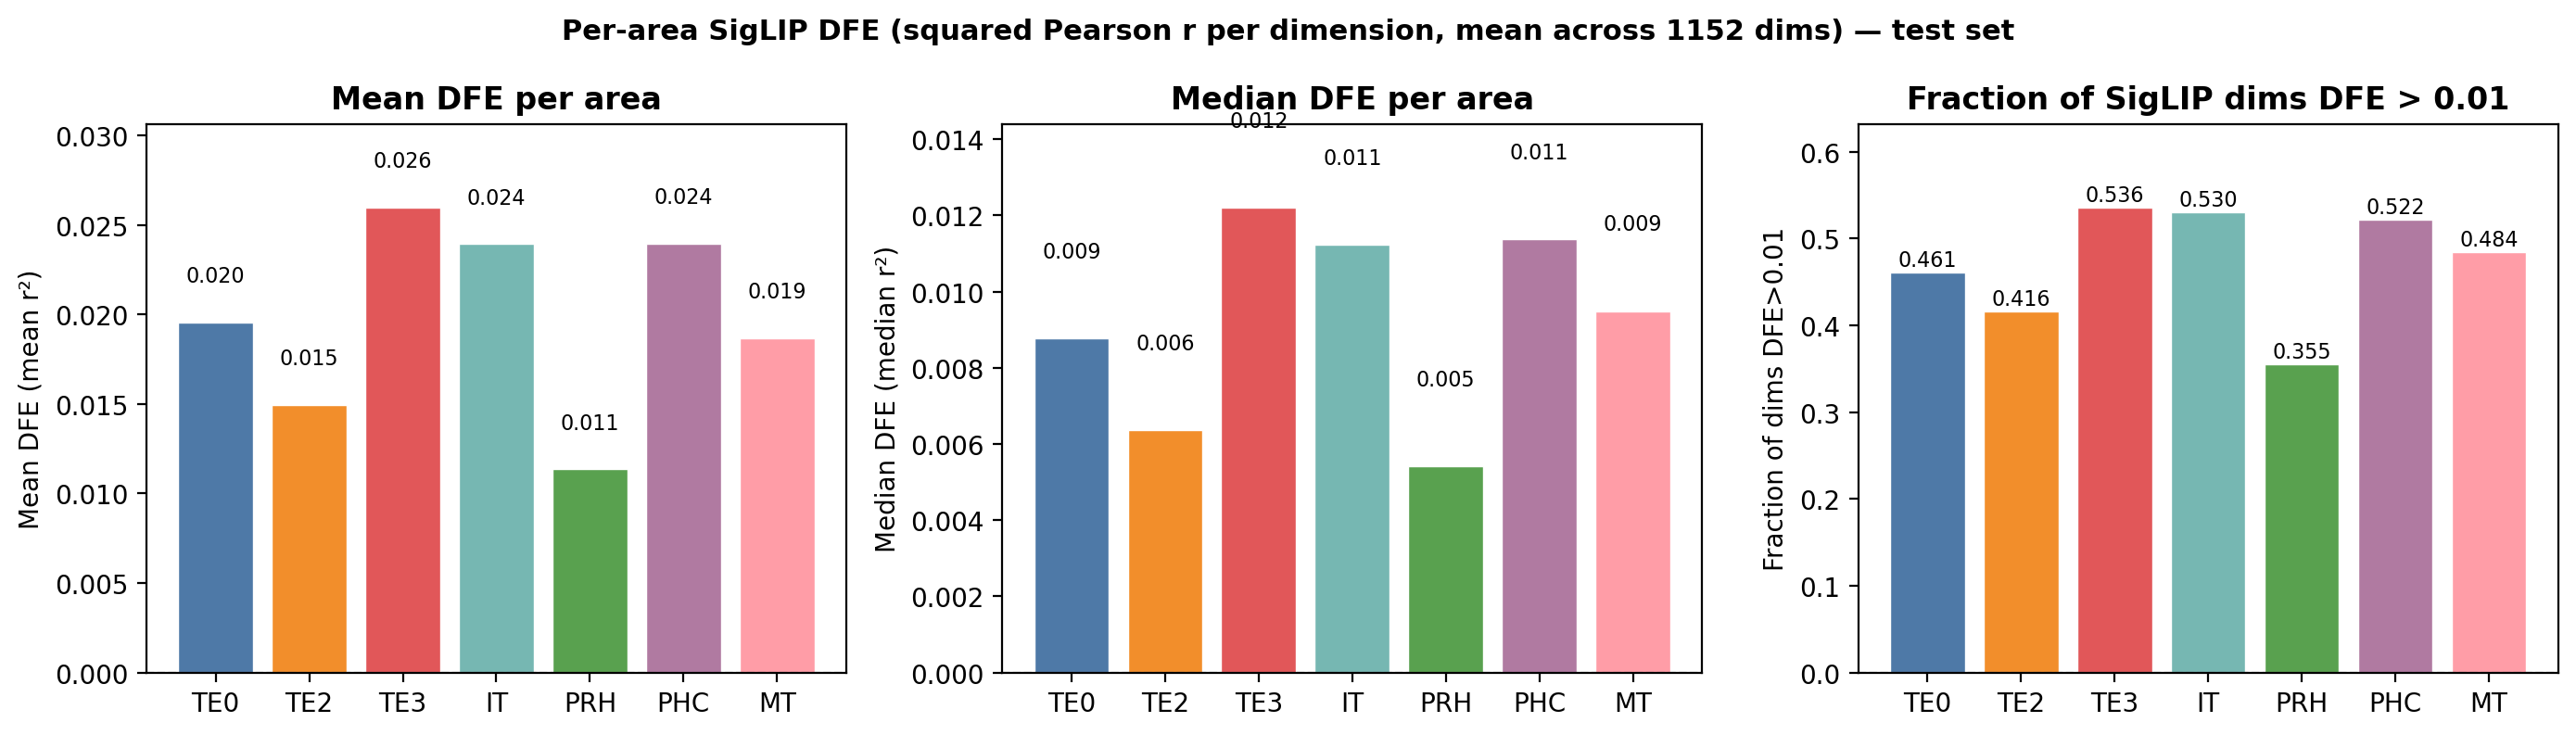

In [21]:
areas_dfe  = [a for a in areas_present if a in dfe_results]
colors_dfe = [AREA_COLORS[a] for a in areas_dfe]
x = np.arange(len(areas_dfe))

mean_dfe   = [dfe_results[a].mean()        for a in areas_dfe]
median_dfe = [np.median(dfe_results[a])    for a in areas_dfe]
frac_01    = [np.mean(dfe_results[a] > 0.01) for a in areas_dfe]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, vals, ylabel, title in [
    (axes[0], mean_dfe,   'Mean DFE (mean r²)',    'Mean DFE per area'),
    (axes[1], median_dfe, 'Median DFE (median r²)', 'Median DFE per area'),
    (axes[2], frac_01,    'Fraction of dims DFE>0.01', 'Fraction of SigLIP dims DFE > 0.01'),
]:
    bars = ax.bar(x, vals, color=colors_dfe, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.002, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
    ax.axhline(0, color='grey', ls='--', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(areas_dfe, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.18 if max(vals) > 0 else 0.1)

fig.suptitle('Per-area SigLIP DFE (squared Pearson r per dimension, mean across 1152 dims) — test set',
             fontsize=11, fontweight='bold')
fig.tight_layout()
plt.show()
